# First-Pitch Outcome Prediction — MLB Statcast
## Binary Classification: Hit Into Play vs. Not In Play

This notebook builds and validates machine learning models to predict whether a batter will make contact on the **first pitch** of an at-bat, using MLB Statcast data (2024–2025 seasons).

### Pipeline Overview
1. **Data Ingestion** — Load Statcast pitch-by-pitch data via `pybaseball`
2. **Batter Profile** — Isolate first-pitch at-bats for the selected hitter and compute descriptive statistics
3. **Feature Engineering** — includes sequential in-game context features (`pitcher_pitch_count_in_game`, `batter_prior_hip_count_in_game`) from sidecar parquet
3. **Feature Engineering** — Build batter and pitcher feature matrices; encode game-state context
4. **Class Balancing** — Address target imbalance with SMOTE oversampling
5. **Model Training** — Train Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost, and ANN classifiers
6. **Evaluation** — Compare models with confusion matrices, accuracy, precision, recall, and F1 scores
7. **Validation** — Assess generalization of all seven models on a held-out 2025 late-season dataset
8. **Summary** — Generalization gap heatmap and side-by-side comparison across all models

---

## 1. Data Ingestion

Load pitch-by-pitch Statcast data for the 2024 season through mid-2025. Caching is enabled to avoid redundant API calls.

In [71]:
# ── Imports & Configuration ───────────────────────────────────────────────────
from pybaseball import statcast, cache
import pandas as pd
import warnings
import sys

warnings.filterwarnings('ignore')
cache.enable()

sys.path.insert(0, '.')
from statcast_loader import load_statcast, list_cached_ranges

# Date range for training data
TRAIN_START  = "2024-03-28"
TRAIN_END    = "2025-08-01"
VAL_START  = "2025-08-02"
VAL_END    = "2025-09-28"
DECAY_RATE   = 0.004   # exp(-0.004 * 180) ≈ 0.49 → half-weight ~6 months ago
BATTER_LAST_NAME = "Butler"
BATTER_FIRST_NAME = "Lawrence"

# Load Training data
table = load_statcast(TRAIN_START, TRAIN_END)
table['pitch_id'] = table.index

# Load validation data
table_validation = load_statcast(VAL_START, VAL_END)
table_full       = load_statcast(TRAIN_START, VAL_END)

table_validation['pitch_id'] = table_validation.index
table_full['pitch_id']       = table_full.index

print(f"Validation pitches : {len(table_validation):,}")
print(f"Full dataset size  : {len(table_full):,}")


# Quick peek at loaded data
print(f"Loaded {len(table):,} pitches spanning {TRAIN_START} → {TRAIN_END}")
print(f"Columns: {table.shape[1]}")
table.head(1000).to_csv('table_example.csv')

Loading from cache: statcast_20240328_20250801.parquet  (173.5 MB)
Loaded 1,250,482 pitches  (2024-03-28 → 2025-08-01)
Loaded 1,250,482 pitches spanning 2024-03-28 → 2025-08-01
Columns: 119


In [72]:
# ── Load Sequential Context Features from Sidecar Parquet ──────────────────
# Generate this file once with:
#   python build_context_features.py <training_parquet>
#
# Columns added:
#   pitcher_pitch_count_in_game    — pitches thrown by pitcher BEFORE this pitch
#   batter_prior_hip_count_in_game — first-pitch HIPs by batter BEFORE this AB
import os

CONTEXT_COLS  = ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game',
                 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count']
TRAIN_CONTEXT = f'statcast_{TRAIN_START.replace("-","")}_{TRAIN_END.replace("-","")}_context_features.parquet'

if os.path.exists(TRAIN_CONTEXT):
    ctx_train = pd.read_parquet(TRAIN_CONTEXT)
    # Drop any pre-existing context columns before merge to avoid _x/_y collision
    table = table.drop(columns=[c for c in CONTEXT_COLS if c in table.columns], errors='ignore')
    table = table.merge(ctx_train, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table.columns:
            table[col] = table[col].fillna(0).astype(int)
        else:
            table[col] = 0
            print(f'  NOTE: {col} not in sidecar — set to 0. Regenerate sidecar.')
    print(f'Training context features loaded: {len(ctx_train):,} rows')
    print(table[CONTEXT_COLS].describe().round(2))
else:
    print(f'WARNING: {TRAIN_CONTEXT} not found — running without context features.')
    print('Run: python build_context_features.py <training_parquet>')
    for col in CONTEXT_COLS:
        table[col] = 0

# Refresh pitch_id after merge
table['pitch_id'] = table.index

Training context features loaded: 1,250,482 rows
       pitcher_pitch_count_in_game  batter_prior_hip_count_in_game  \
count                   1250482.00                      1250482.00   
mean                         30.33                            0.18   
std                          26.54                            0.41   
min                           0.00                            0.00   
25%                           8.00                            0.00   
50%                          21.00                            0.00   
75%                          50.00                            0.00   
max                         117.00                            4.00   

       pitcher_pitch_count_prior_game  batter_prior_game_hip_count  
count                      1250482.00                   1250482.00  
mean                            56.53                         1.14  
std                             36.78                         0.45  
min                              0.00       

## 2. Batter Selection & First-Pitch Profile

Select the target batter and compute first-pitch descriptive statistics. These metrics help contextualize model inputs and serve as a sanity check.

In [73]:
# ── Batter Lookup ─────────────────────────────────────────────────────────────
from pybaseball import playerid_lookup

hitter_table = playerid_lookup(BATTER_LAST_NAME, BATTER_FIRST_NAME)
hitter_id    = hitter_table['key_mlbam'][0]
print(f"Batter ID: {hitter_id}  ({hitter_table['name_first'][0]} {hitter_table['name_last'][0]})")

Batter ID: 671732  (lawrence butler)


In [74]:
# ── First-Pitch Descriptive Statistics ───────────────────────────────────────
import numpy as np
import pandas as pd

first_pitch = table[(table['balls'] == 0) & (table['strikes'] == 0)]
batter = first_pitch[first_pitch['batter'] == hitter_id]

# Outcome categories
STRIKE_TYPES   = ['called_strike', 'swinging_strike', 'foul', 'foul_bunt',
                  'foul_tip', 'swinging_strike_blocked', 'missed_bunt',
                  'bunt_foul_tip', 'automatic_strike']
BALL_TYPES     = ['ball', 'blocked_ball', 'hit_by_pitch', 'pitchout',
                  'automatic_ball', 'intent_ball']
IN_PLAY_TYPES  = ['hit_into_play']
CONTACT_TYPES  = ['foul', 'foul_bunt', 'hit_into_play', 'foul_tip', 'bunt_foul_tip']
SWING_TYPES    = ['swinging_strike', 'swinging_strike_blocked', 'foul', 'foul_bunt',
                  'hit_into_play', 'foul_tip', 'bunt_foul_tip']

def count_outcomes(desc_series, outcome_list):
    return sum(desc_series.value_counts().get(o, 0) for o in outcome_list)

vc = batter['description'].value_counts()

total          = vc.sum()
total_strikes  = count_outcomes(batter['description'], STRIKE_TYPES)
total_balls    = count_outcomes(batter['description'], BALL_TYPES)
count_in_play  = count_outcomes(batter['description'], IN_PLAY_TYPES)
count_contact  = count_outcomes(batter['description'], CONTACT_TYPES)
count_swings   = count_outcomes(batter['description'], SWING_TYPES)

metrics = {
    'Total at-bats':                        total,
    'Strike rate (%)':                      round(total_strikes / total * 100, 1),
    'Ball rate (%)':                        round(total_balls   / total * 100, 1),
    'Hit into play rate (%)':               round(count_in_play / total * 100, 1),
    'Swing rate (%)':                       round(count_swings  / total * 100, 1),
    'Contact rate (%)':                     round(count_contact / total * 100, 1),
    'Swing rate on strikes (%)':            round(count_swings  / total_strikes * 100, 1),
    'Contact rate on strikes (%)':          round(count_contact / total_strikes * 100, 1),
    'Hit into play rate on strikes (%)':    round(count_in_play / total_strikes * 100, 1),
}

print("=" * 48)
print("  First-Pitch Batter Profile")
print("=" * 48)
for k, v in metrics.items():
    print(f"  {k:<40} {v}")
print("=" * 48)

  First-Pitch Batter Profile
  Total at-bats                            932
  Strike rate (%)                          44.7
  Ball rate (%)                            42.3
  Hit into play rate (%)                   13.0
  Swing rate (%)                           34.1
  Contact rate (%)                         26.0
  Swing rate on strikes (%)                76.3
  Contact rate on strikes (%)              58.0
  Hit into play rate on strikes (%)        29.0


## 3. Feature Engineering

### 3a. Batter Matrix — Outcome Simplification
All pitch outcomes are collapsed into a binary target:
- **`hit_into_play`** — batter made contact and the ball entered the field of play
- **`not_in_play`** — all other outcomes (called strikes, swinging strikes, balls, etc.)


In [75]:
import numpy as np

# ── Map All Outcomes → Binary Label ──────────────────────────────────────────
NOT_IN_PLAY_OUTCOMES = [
    'called_strike', 'foul', 'swinging_strike', 'swinging_strike_blocked',
    'foul_tip', 'foul_bunt', 'missed_bunt', 'blocked_ball', 'ball',
    'bunt_foul_tip', 'automatic_strike', 'automatic_ball', 'intent_ball',
    'pitchout', 'hit_by_pitch',
]

new_batter = batter.drop('events', axis=1)
for outcome in NOT_IN_PLAY_OUTCOMES:
    new_batter = new_batter.replace(outcome, 'not_in_play')

# ── Initialize Pitcher Feature DataFrame ──────────────────────────────────────
PITCH_TYPES = ['FF','SI','SL','CH','FC','ST','CU','FS','KC','None',
               'SV','KN','FA','EP','FO','CS','SC','PO','UN']

pitchers   = new_batter['pitcher'].unique()
pitcher_cols = (
    ['pitcher', 'strike_percent', 'swing_percent_on_strikes',
     'contact_percent_on_strikes', 'in_play_percent_on_strikes']
    + [f'{pt}_percent' for pt in PITCH_TYPES]
)
pitchers_1 = pd.DataFrame(pitchers, columns=['pitcher'])
for col in pitcher_cols[1:]:
    pitchers_1[col] = 0.0

# ── Drop Redundant / High-Cardinality Columns ─────────────────────────────────
DROP_COLS_1 = [
    'game_date','spin_dir','batter','zone','spin_axis','spin_rate_deprecated',
    'break_angle_deprecated','break_length_deprecated','des','game_type','type',
    'hit_location','bb_type','balls','strikes','game_year','hc_x','hc_y',
    'tfs_deprecated','tfs_zulu_deprecated','umpire','sv_id','player_name',
    'hit_distance_sc','launch_speed','launch_angle',
    'fielder_2','fielder_3','fielder_4','fielder_5','fielder_6','fielder_7','fielder_8','fielder_9',
    'home_team','away_team','home_score','away_score','bat_score','fld_score',
    'post_away_score','post_home_score','post_bat_score','post_fld_score',
    'release_pos_y','delta_home_win_exp','delta_run_exp','bat_speed','swing_length',
    'estimated_slg_using_speedangle','delta_pitcher_run_exp','hyper_speed',
    'home_score_diff','home_win_exp','age_pit_legacy','age_bat_legacy',
    'age_pit','age_bat','pitcher_days_since_prev_game','batter_days_since_prev_game',
    'pitcher_days_until_next_game','batter_days_until_next_game','pitch_name',
]
DROP_COLS_2 = [
    'if_fielding_alignment','of_fielding_alignment','pitch_type','release_speed',
    'release_pos_x','release_pos_z','vx0','vy0','vz0','ax','ay','az','sz_top',
    'effective_speed','release_spin_rate','release_extension','sz_bot','pfx_x','pfx_z',
    'arm_angle','plate_x','plate_z','api_break_z_with_gravity','api_break_x_arm',
    'api_break_x_batter_in','estimated_ba_using_speedangle','estimated_woba_using_speedangle',
    'woba_value','woba_denom','babip_value','iso_value','launch_speed_angle',
]
DROP_COLS_3 = [
    'bat_score_diff','n_thruorder_pitcher','n_priorpa_thisgame_player_at_bat',
    'attack_angle','attack_direction','swing_path_tilt',
    'intercept_ball_minus_batter_pos_x_inches','intercept_ball_minus_batter_pos_y_inches',
]

# ── Compute decay weights BEFORE game_date is dropped ────────────────────────
# Keyed by pitch_id so they survive the pitcher-feature merge below
TRAIN_END_DT = pd.Timestamp(TRAIN_END)
raw_dates    = pd.to_datetime(new_batter['game_date'], errors='coerce')
days_ago     = (TRAIN_END_DT - raw_dates).dt.days.clip(lower=0).fillna(0)
decay_weights_by_pid = pd.Series(
    np.exp(-DECAY_RATE * days_ago.values),
    index=new_batter['pitch_id'].values
)

batter_clean = (
    new_batter
    .drop(columns=DROP_COLS_1, errors='ignore')
    .drop(columns=DROP_COLS_2, errors='ignore')
    .drop(columns=DROP_COLS_3, errors='ignore')
)

# ── Base Runner Flags ─────────────────────────────────────────────────────────
for base_col in ['on_1b', 'on_2b', 'on_3b']:
    batter_clean[base_col] = batter_clean[base_col].fillna(0)
    batter_clean.loc[batter_clean[base_col] > 0, base_col] = 1

print(f"Feature matrix shape: {batter_clean.shape}")
print(batter_clean.head(5))

Feature matrix shape: (932, 19)
      pitcher    description stand p_throws  on_3b  on_2b  on_1b  \
3454   595928  hit_into_play     L        R      0      0      1   
3521   663765    not_in_play     L        R      0      0      1   
3585   669459    not_in_play     L        L      0      1      1   
3656   543101    not_in_play     L        R      0      0      0   
3700   543101    not_in_play     L        R      0      0      0   

      outs_when_up  inning inning_topbot  game_pk  at_bat_number  \
3454             1       7           Bot   776914             67   
3521             1       5           Bot   776914             49   
3585             2       3           Bot   776914             33   
3656             0       2           Bot   776914             19   
3700             0       1           Bot   776914              6   

      pitch_number  bat_win_exp  pitch_id  pitcher_pitch_count_in_game  \
3454             1        0.971      3454                            9   
35

### 3b. Pitcher Feature Matrix
For each pitcher faced by the batter, compute first-pitch strike rates and pitch-type mix from the full dataset (to avoid data leakage from the batter-specific subset).

In [76]:
# ── Build Pitcher Statistics ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

def compute_pitch_counts(desc_series):
    """Return a dict of first-pitch outcome counts for a pitcher."""
    vc = desc_series.value_counts()
    return {k: vc.get(k, 0) for k in
            ['ball','called_strike','swinging_strike','foul','foul_bunt',
             'hit_into_play','blocked_ball','foul_tip','bunt_foul_tip',
             'swinging_strike_blocked','hit_by_pitch','missed_bunt',
             'pitchout','automatic_strike','automatic_ball','intent_ball']}

for i in range(len(pitchers_1)):
    pitcher_id = pitchers_1['pitcher'].iloc[i]
    select     = first_pitch[first_pitch['pitcher'] == pitcher_id]

    c = compute_pitch_counts(select['description'])

    total_p   = sum(c.values())
    t_strikes = (c['called_strike'] + c['swinging_strike'] + c['foul'] +
                 c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] +
                 c['swinging_strike_blocked'] + c['missed_bunt'] +
                 c['bunt_foul_tip'] + c['automatic_strike'])
    t_contact = c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip']
    t_swings  = (c['swinging_strike'] + c['swinging_strike_blocked'] +
                 c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip'])

    if total_p > 0 and t_strikes > 0:
        pitchers_1.at[i, 'strike_percent']              = t_strikes  / total_p
        pitchers_1.at[i, 'swing_percent_on_strikes']    = t_swings   / t_strikes
        pitchers_1.at[i, 'contact_percent_on_strikes']  = t_contact  / t_strikes
        pitchers_1.at[i, 'in_play_percent_on_strikes']  = c['hit_into_play'] / t_strikes

    # Pitch-type mix
    select_pt = select['pitch_type'].fillna('None')
    pt_vc     = select_pt.value_counts()
    total_pt  = pt_vc.sum()
    if total_pt > 0:
        for pt in PITCH_TYPES:
            pitchers_1.at[i, f'{pt}_percent'] = pt_vc.get(pt, 0) / total_pt

batters_merged = pd.merge(batter_clean, pitchers_1, on='pitcher', how='inner')
print(f"Merged batter + pitcher features: {batters_merged.shape}")
batters_merged.head(10).to_csv('batter_12_head.csv')

Merged batter + pitcher features: (932, 42)


### 3c. Game-State Context — Previous At-Bat & Sequential In-Game Features
Encode what happened in the immediately preceding at-bat (result and pitch count) to capture momentum and fatigue signals. Two additional sequential features are loaded from the context sidecar (generated by `build_context_features.py`):

- **`pitcher_pitch_count_in_game`** — pitches thrown by the pitcher before this AB
- **`batter_prior_hip_count_in_game`** — first-pitch HIPs by the batter earlier in this game

In [77]:
# ── Previous At-Bat Context Features ─────────────────────────────────────────
EVENT_MAP = {
    'hit_by_pitch': 'walk',    'intent_walk': 'walk',    'catcher_interf': 'walk',
    'home_run':     'extra_base_hit', 'triple': 'extra_base_hit', 'double': 'extra_base_hit',
    'force_out':    'field_out',  'fielders_choice': 'field_out',  'grounded_into_double_play': 'field_out',
    'double_play':  'field_out',  'fielders_choice_out': 'field_out', 'sac_bunt': 'field_out',
    'sac_fly':      'field_out',  'field_error': 'single',
    'strikeout_double_play': 'strikeout',
}

batters_merged['prev_pitch_result']    = ''
batters_merged['prev_ab_pitch_count']  = 0

for i in range(len(batter_clean)):
    select_id   = batter_clean['pitch_id'].iloc[i]
    select_game = batters_merged['game_pk'].iloc[i]
    select_inn  = batters_merged['inning'].iloc[i]
    select_top  = batters_merged['inning_topbot'].iloc[i]

    prev = table[table['pitch_id'] == (select_id + 1)]

    if prev.empty:
        batters_merged.at[i, 'prev_pitch_result'] = 'start_of_game'
        continue

    prev_game = prev['game_pk'].values[0]
    prev_inn  = prev['inning'].values[0]
    prev_top  = prev['inning_topbot'].values[0]

    if prev_game != select_game:
        batters_merged.at[i, 'prev_pitch_result'] = 'start_of_game'
    elif prev_inn != select_inn or prev_top != select_top:
        batters_merged.at[i, 'prev_pitch_result'] = 'start_of_inning'
    else:
        batters_merged.at[i, 'prev_pitch_result']   = prev['events'].values[0]
        batters_merged.at[i, 'prev_ab_pitch_count']  = prev['pitch_number'].values[0]

# Apply event consolidation map
batters_merged.replace(EVENT_MAP, inplace=True)

# Move target column to end
desc_col = batters_merged.pop('description')
batters_merged.insert(len(batters_merged.columns), 'description', desc_col)

batters_merged.head(100).to_csv('seq_example.csv')
print(f"Unique prev_pitch_result values: {batters_merged['prev_pitch_result'].unique()}")
print(batters_merged.head(5))

# ── Align decay weights to rows that survived the merge ─────────────────────
# batters_merged is an inner join so some pitch_ids may have been dropped
aligned_weights = (
    decay_weights_by_pid
    .reindex(batters_merged['pitch_id'].values)
    .fillna(decay_weights_by_pid.mean())
    .values
)
print(f'Decay weights aligned: {len(aligned_weights)} rows')
print(f'Weight range: {aligned_weights.min():.4f} – {aligned_weights.max():.4f}')

Unique prev_pitch_result values: ['single' 'field_out' 'start_of_inning' 'extra_base_hit' 'walk'
 'start_of_game' 'strikeout']
   pitcher stand p_throws  on_3b  on_2b  on_1b  outs_when_up  inning  \
0   595928     L        R      0      0      1             1       7   
1   663765     L        R      0      0      1             1       5   
2   669459     L        L      0      1      1             2       3   
3   543101     L        R      0      0      0             0       2   
4   543101     L        R      0      0      0             0       1   

  inning_topbot  game_pk  ...  FA_percent  EP_percent  FO_percent  CS_percent  \
0           Bot   776914  ...         0.0         0.0         0.0         0.0   
1           Bot   776914  ...         0.0         0.0         0.0         0.0   
2           Bot   776914  ...         0.0         0.0         0.0         0.0   
3           Bot   776914  ...         0.0         0.0         0.0         0.0   
4           Bot   776914  ...      

## 4. Preprocessing — Encoding, Balancing & Scaling

In [78]:
# ── Encode & Split Features / Target ─────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

CATEGORICAL_COLS  = ['p_throws', 'outs_when_up', 'stand', 'prev_pitch_result']
DROP_BEFORE_MODEL = ['pitcher', 'game_pk', 'inning', 'inning_topbot', 'pitch_number']

# ── Fixed category sets — prevents feature count varying with training window ──
# OneHotEncoder normally infers categories from the training data; if a value
# is absent from one window it produces fewer columns, breaking train/validation
# alignment. Fixing them here guarantees a stable feature matrix regardless of
# which date range is used.
FIXED_CATEGORIES = [
    ['L', 'R'],                                          # p_throws
    ['0', '1', '2'],                                     # outs_when_up
    ['L', 'R', 'S'],                                     # stand
    ['', 'extra_base_hit', 'field_out', 'hit_by_pitch',  # prev_pitch_result
     'single', 'start_of_game', 'start_of_inning',
     'strikeout', 'walk'],
]

dataset = batters_merged.drop(columns=DROP_BEFORE_MODEL)

X_raw = dataset.iloc[:, :-1]
y     = dataset.iloc[:,  -1]

# ── Diagnostic: print column list so mismatches across windows are visible ───
print(f'X_raw columns ({len(X_raw.columns)}):')
print(sorted(X_raw.columns.tolist()))

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(
        handle_unknown='ignore',
        categories=FIXED_CATEGORIES,
    ), CATEGORICAL_COLS)],
    remainder='passthrough'
)
X = ct.fit_transform(X_raw)

le = LabelEncoder()
y  = le.fit_transform(y)

print(f"Feature matrix: {X.shape}  |  Classes: {le.classes_}")

X_raw columns (38):
['CH_percent', 'CS_percent', 'CU_percent', 'EP_percent', 'FA_percent', 'FC_percent', 'FF_percent', 'FO_percent', 'FS_percent', 'KC_percent', 'KN_percent', 'None_percent', 'PO_percent', 'SC_percent', 'SI_percent', 'SL_percent', 'ST_percent', 'SV_percent', 'UN_percent', 'at_bat_number', 'bat_win_exp', 'batter_prior_game_hip_count', 'batter_prior_hip_count_in_game', 'contact_percent_on_strikes', 'in_play_percent_on_strikes', 'on_1b', 'on_2b', 'on_3b', 'outs_when_up', 'p_throws', 'pitch_id', 'pitcher_pitch_count_in_game', 'pitcher_pitch_count_prior_game', 'prev_ab_pitch_count', 'prev_pitch_result', 'stand', 'strike_percent', 'swing_percent_on_strikes']
Feature matrix: (932, 51)  |  Classes: ['hit_into_play' 'not_in_play']


Class distribution BEFORE SMOTE: Counter({np.int64(1): 811, np.int64(0): 121})
Class distribution AFTER  SMOTE: Counter({np.int64(0): 811, np.int64(1): 811})


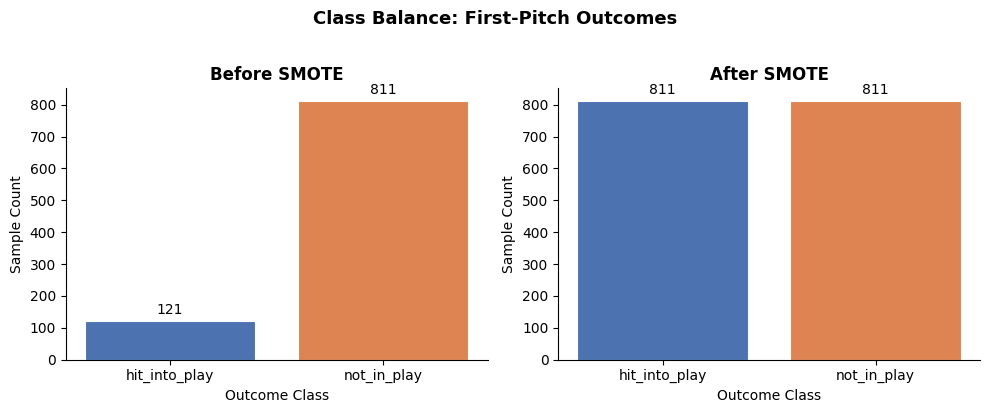

In [79]:
# ── SMOTE Oversampling — Address Class Imbalance ──────────────────────────────
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE

print("Class distribution BEFORE SMOTE:", Counter(y))

smote      = SMOTE(sampling_strategy='minority', random_state=42)
X_sm, y_sm = smote.fit_resample(X, y)

# ── Propagate decay weights through SMOTE ─────────────────────────────────
# Original rows keep their decay weights; synthetic minority rows receive
# the mean weight of real minority-class rows.
# y is already integer-encoded by le in cell 17, so use le.classes_ directly.
minority_idx   = list(le.classes_).index('hit_into_play')
minority_mask  = (y == minority_idx)
mean_minority_w = aligned_weights[minority_mask].mean() if minority_mask.any() else 1.0
n_synthetic    = X_sm.shape[0] - X.shape[0]
sm_weights     = np.concatenate([
    aligned_weights,
    np.full(n_synthetic, mean_minority_w),
])

print("Class distribution AFTER  SMOTE:", Counter(y_sm))

# Plot class balance comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [Counter(y), Counter(y_sm)],
    ['Before SMOTE', 'After SMOTE']
):
    labels = [le.classes_[k] for k in sorted(counts.keys())]
    values = [counts[k] for k in sorted(counts.keys())]
    bars = ax.bar(labels, values, color=['#4C72B0','#DD8452'], edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, padding=3, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Sample Count')
    ax.set_xlabel('Outcome Class')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Class Balance: First-Pitch Outcomes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_balance.png', bbox_inches='tight', dpi=150)
plt.show()

In [80]:
# ── Train/Test Split & Feature Scaling ───────────────────────────────────────
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TEST_SIZE   = 0.25
RANDOM_SEED = 0

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_sm, y_sm, sm_weights, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

sc      = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing  samples : {X_test.shape[0]:,}")
print(f"Feature count    : {X_train.shape[1]}")

Training samples : 1,216
Testing  samples : 406
Feature count    : 51


## 5. Model Training & Evaluation

Six classifiers are trained: Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost, and ANN. LightGBM uses `is_unbalance=True` and CatBoost uses `auto_class_weights='Balanced'` to natively up-weight the minority class (`hit_into_play`) during training. A shared evaluation helper plots the confusion matrix and prints accuracy, precision, recall, and F1 for each model.

In [81]:
# ── Shared Evaluation Helper ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)

def evaluate_model(model_name, y_true, y_pred, class_names=None):
    """Print metrics and plot confusion matrix for a classifier."""
    if class_names is None:
        class_names = [str(c) for c in sorted(set(y_true))]

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}  (weighted)")
    print(f"  F1 Score  : {f1:.4f}  (weighted)")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

model_results = []   # collect results for final comparison chart
CLASS_NAMES   = list(le.classes_)
print("Evaluation helper defined. Classes:", CLASS_NAMES)

Evaluation helper defined. Classes: ['hit_into_play', 'not_in_play']


### 5a. Decision Tree


  Decision Tree
  Accuracy  : 0.7808
  Precision : 0.7807  (weighted)
  Recall    : 0.7808  (weighted)
  F1 Score  : 0.7807  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.79      0.80      0.79       211
  not_in_play       0.78      0.76      0.77       195

     accuracy                           0.78       406
    macro avg       0.78      0.78      0.78       406
 weighted avg       0.78      0.78      0.78       406



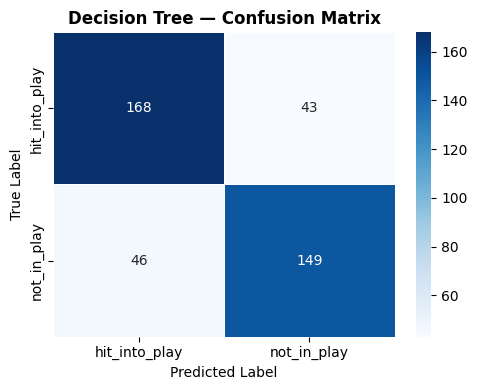

In [82]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_SEED)
dt_clf.fit(X_train, y_train, sample_weight=w_train)

y_pred_dt = dt_clf.predict(X_test)
model_results.append(evaluate_model("Decision Tree", y_test, y_pred_dt, CLASS_NAMES))

### 5b. Random Forest


  Random Forest
  Accuracy  : 0.8990
  Precision : 0.9000  (weighted)
  Recall    : 0.8990  (weighted)
  F1 Score  : 0.8991  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.92      0.88      0.90       211
  not_in_play       0.88      0.92      0.90       195

     accuracy                           0.90       406
    macro avg       0.90      0.90      0.90       406
 weighted avg       0.90      0.90      0.90       406



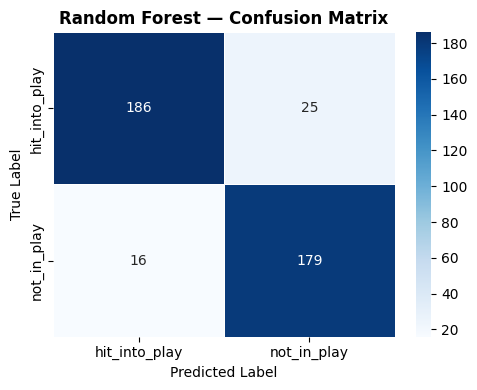

In [83]:
# ── Random Forest ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=RANDOM_SEED)
rf_clf.fit(X_train, y_train, sample_weight=w_train)

y_pred_rf = rf_clf.predict(X_test)
model_results.append(evaluate_model("Random Forest", y_test, y_pred_rf, CLASS_NAMES))

### 5c. Artificial Neural Network (ANN)

In [84]:
# ── ANN Architecture & Training ───────────────────────────────────────────────
import tensorflow as tf

X_train_ann = np.asarray(X_train).astype('float32')
y_train_ann = np.asarray(y_train).astype('float32')
w_train_ann = np.asarray(w_train).astype('float32')

ann = tf.keras.models.Sequential([
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=8,  activation='relu'),
    tf.keras.layers.Dense(units=4,  activation='relu'),
    tf.keras.layers.Dense(units=1,  activation='sigmoid'),
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = ann.fit(
    X_train_ann, y_train_ann,
    sample_weight=w_train_ann,
    batch_size=100,
    epochs=200,
    validation_split=0.1,
    verbose=0,
)
print("ANN training complete.")

ANN training complete.


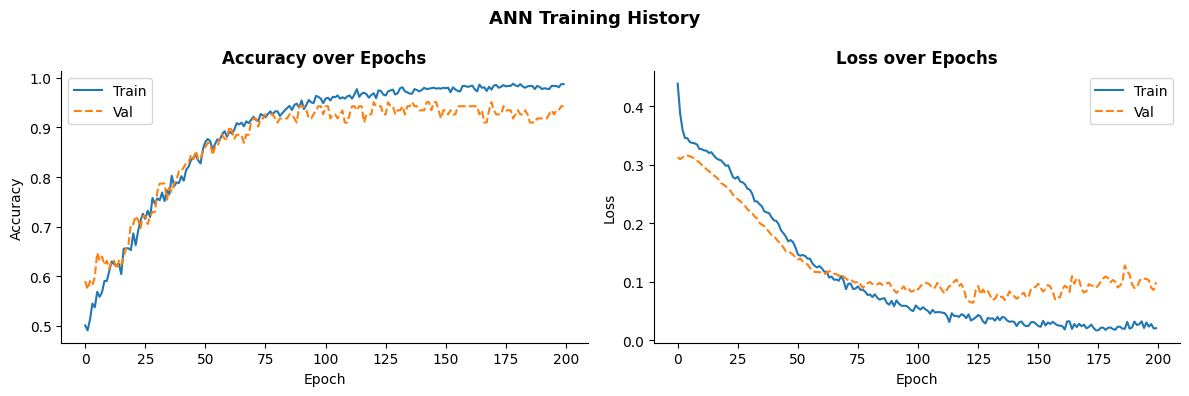

In [85]:
# ── ANN Training Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy over Epochs', 'Loss over Epochs']
):
    ax.plot(history.history[metric[0]],   label='Train', linewidth=1.5)
    ax.plot(history.history[metric[1]],   label='Val',   linewidth=1.5, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric[0].capitalize())
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('ANN Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ann_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

  ANN
  Accuracy  : 0.9187
  Precision : 0.9194  (weighted)
  Recall    : 0.9187  (weighted)
  F1 Score  : 0.9186  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.90      0.94      0.92       211
  not_in_play       0.94      0.89      0.91       195

     accuracy                           0.92       406
    macro avg       0.92      0.92      0.92       406
 weighted avg       0.92      0.92      0.92       406



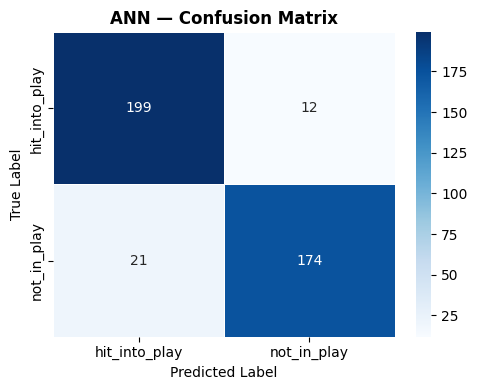

In [86]:
# ── ANN Test-Set Evaluation ───────────────────────────────────────────────────
y_pred_ann_prob = ann.predict(X_test)
y_pred_ann      = (y_pred_ann_prob > 0.5).astype(np.int_)

model_results.append(evaluate_model("ANN", y_test, y_pred_ann, CLASS_NAMES))

### 5d. XGBoost


  XGBoost
  Accuracy  : 0.9113
  Precision : 0.9175  (weighted)
  Recall    : 0.9113  (weighted)
  F1 Score  : 0.9112  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.97      0.86      0.91       211
  not_in_play       0.86      0.97      0.91       195

     accuracy                           0.91       406
    macro avg       0.92      0.91      0.91       406
 weighted avg       0.92      0.91      0.91       406



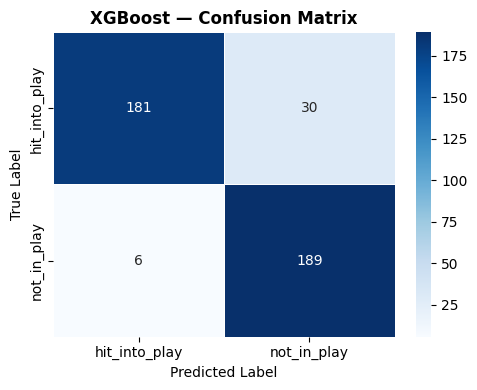

In [87]:
# ── XGBoost Classifier ───────────────────────────────────────────────────
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
)
xgb_clf.fit(X_train, y_train, sample_weight=w_train)

y_pred_xgb = xgb_clf.predict(X_test)
model_results.append(evaluate_model('XGBoost', y_test, y_pred_xgb, CLASS_NAMES))

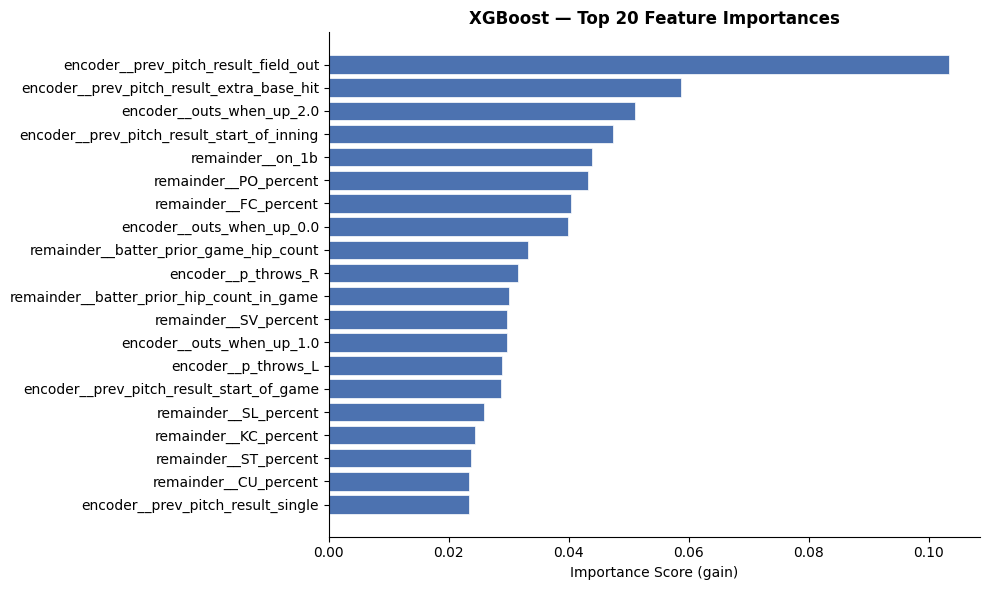

In [88]:
# ── XGBoost Feature Importance (Top 20) ────────────────────────────────────
import numpy as np

importances = xgb_clf.feature_importances_
top_n      = 20
top_idx    = np.argsort(importances)[::-1][:top_n]
top_scores = importances[top_idx]

try:
    feature_names = ct.get_feature_names_out()
    top_labels = [feature_names[i] for i in top_idx]
except Exception:
    top_labels = [f'Feature {i}' for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_labels[::-1], top_scores[::-1],
        color='#4C72B0', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Importance Score (gain)')
ax.set_title('XGBoost — Top 20 Feature Importances', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 5e. LightGBM


  LightGBM
  Accuracy  : 0.9138
  Precision : 0.9205  (weighted)
  Recall    : 0.9138  (weighted)
  F1 Score  : 0.9137  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.97      0.86      0.91       211
  not_in_play       0.86      0.97      0.92       195

     accuracy                           0.91       406
    macro avg       0.92      0.92      0.91       406
 weighted avg       0.92      0.91      0.91       406



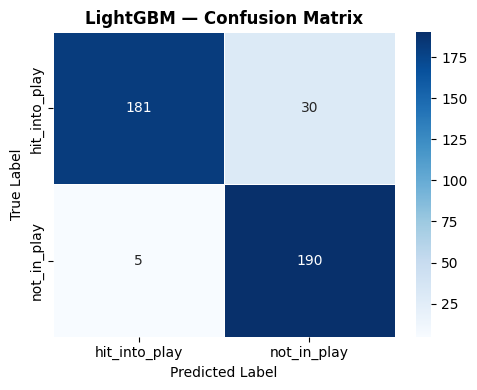

In [89]:
# ── LightGBM Classifier ──────────────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '--quiet'])

import lightgbm as lgb
from collections import Counter

# is_unbalance=True internally reweights classes by their inverse frequency,
# directing more learning signal toward the minority class (hit_into_play)
lgbm_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=RANDOM_SEED,
    verbose=-1,
)
lgbm_clf.fit(X_train, y_train, sample_weight=w_train)

y_pred_lgbm = lgbm_clf.predict(X_test)
model_results.append(evaluate_model('LightGBM', y_test, y_pred_lgbm, CLASS_NAMES))

### 5f. CatBoost


  CatBoost
  Accuracy  : 0.9236
  Precision : 0.9276  (weighted)
  Recall    : 0.9236  (weighted)
  F1 Score  : 0.9236  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.97      0.88      0.92       211
  not_in_play       0.88      0.97      0.92       195

     accuracy                           0.92       406
    macro avg       0.93      0.93      0.92       406
 weighted avg       0.93      0.92      0.92       406



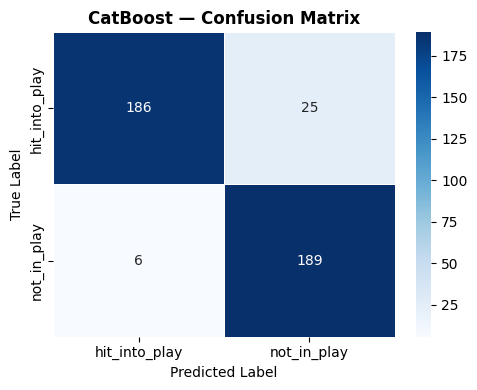

In [90]:
# ── CatBoost Classifier ──────────────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '--quiet'])

from catboost import CatBoostClassifier
from collections import Counter

# auto_class_weights='Balanced' automatically sets per-class weights
# inversely proportional to class frequency — no manual calculation needed.
# CatBoost also handles the sparse one-hot encoded matrix well natively.
cat_clf = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    auto_class_weights='Balanced',
    random_seed=RANDOM_SEED,
    verbose=0,
)
cat_clf.fit(X_train, y_train, sample_weight=w_train)

y_pred_cat = cat_clf.predict(X_test)
model_results.append(evaluate_model('CatBoost', y_test, y_pred_cat, CLASS_NAMES))

## 6. Model Comparison

               accuracy  precision  recall      f1
model                                             
Decision Tree    0.7808     0.7807  0.7808  0.7807
Random Forest    0.8990     0.9000  0.8990  0.8991
ANN              0.9187     0.9194  0.9187  0.9186
XGBoost          0.9113     0.9175  0.9113  0.9112
LightGBM         0.9138     0.9205  0.9138  0.9137
CatBoost         0.9236     0.9276  0.9236  0.9236


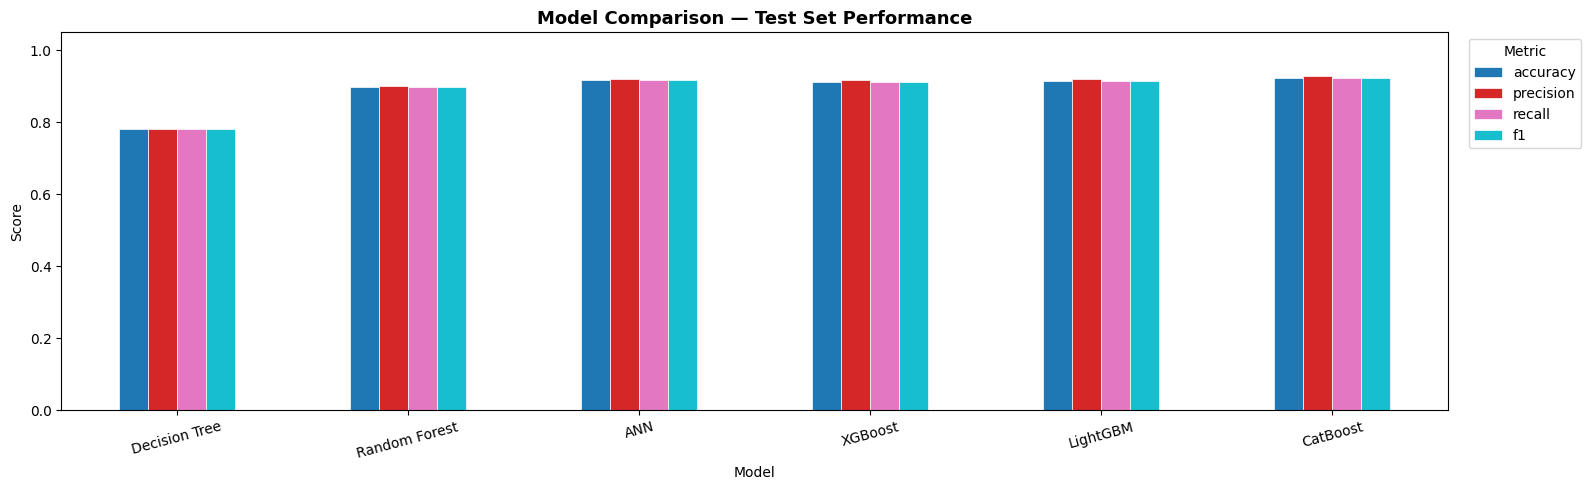

In [91]:
# ── Side-by-Side Model Performance Chart ────────────────────────────────────
results_df = pd.DataFrame(model_results).set_index('model')
print(results_df.round(4))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
results_df[metrics_to_plot].plot(
    kind='bar', figsize=(16, 5), edgecolor='white', linewidth=0.5,
    colormap='tab10', rot=15
)
plt.title('Model Comparison — Test Set Performance', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1.05)
plt.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Validation Study — All-Model Generalization

All six classifiers (Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost, and ANN) are evaluated on a **completely held-out** late-2025 dataset (Aug–Sep 2025) to assess generalization. Pitcher statistics are drawn from the full 2024–2025 data to minimize leakage.

In [92]:
# ── Load Sequential Context Features for Validation & Full Tables ────────────
VAL_CONTEXT  = f'statcast_{VAL_START.replace("-","")}_{VAL_END.replace("-","")}_context_features.parquet'
FULL_CONTEXT = f'statcast_{TRAIN_START.replace("-","")}_{VAL_END.replace("-","")}_context_features.parquet'

if os.path.exists(VAL_CONTEXT):
    ctx_val = pd.read_parquet(VAL_CONTEXT)
    # Drop any pre-existing context columns before merge to avoid _x/_y collision
    table_validation = table_validation.drop(columns=[c for c in CONTEXT_COLS if c in table_validation.columns], errors='ignore')
    table_validation = table_validation.merge(ctx_val, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table_validation.columns:
            table_validation[col] = table_validation[col].fillna(0).astype(int)
        else:
            table_validation[col] = 0
            print(f'  NOTE: {col} not in sidecar — set to 0. Regenerate sidecar.')
    print(f'Validation context features loaded: {len(ctx_val):,} rows')
else:
    print(f'WARNING: {VAL_CONTEXT} not found — context features set to 0.')
    print('Run: python build_context_features.py <validation_parquet>')
    for col in CONTEXT_COLS:
        table_validation[col] = 0

if os.path.exists(FULL_CONTEXT):
    ctx_full = pd.read_parquet(FULL_CONTEXT)
    # Drop any pre-existing context columns before merge to avoid _x/_y collision
    table_full = table_full.drop(columns=[c for c in CONTEXT_COLS if c in table_full.columns], errors='ignore')
    table_full = table_full.merge(ctx_full, on='pitch_id', how='left')
    for col in CONTEXT_COLS:
        if col in table_full.columns:
            table_full[col] = table_full[col].fillna(0).astype(int)
        else:
            table_full[col] = 0
            print(f'  NOTE: {col} not in sidecar — set to 0. Regenerate sidecar.')
    print(f'Full dataset context features loaded: {len(ctx_full):,} rows')
else:
    print(f'WARNING: {FULL_CONTEXT} not found — context features set to 0.')
    for col in CONTEXT_COLS:
        table_full[col] = 0

# Refresh pitch_ids after merges
table_validation['pitch_id'] = table_validation.index
table_full['pitch_id']       = table_full.index

Loading from cache: statcast_20250802_20250928.parquet  (36.1 MB)
Loaded 230,144 pitches  (2025-08-02 → 2025-09-28)
Loading from cache: statcast_20240328_20250928.parquet  (202.7 MB)
Loaded 1,480,626 pitches  (2024-03-28 → 2025-09-28)
Validation pitches : 230,144
Full dataset size  : 1,480,626
Validation context features loaded: 230,144 rows
Full dataset context features loaded: 1,480,626 rows


In [93]:
# ── Build Validation Batter Matrix ───────────────────────────────────────────
first_pitch_validation = table_validation[
    (table_validation['balls'] == 0) & (table_validation['strikes'] == 0)
]
batter_validation = first_pitch_validation[first_pitch_validation['batter'] == hitter_id]

first_pitch_full = table_full[
    (table_full['balls'] == 0) & (table_full['strikes'] == 0)
]

# Collapse outcomes to binary
new_batter_val = batter_validation.drop('events', axis=1)
for outcome in NOT_IN_PLAY_OUTCOMES:
    new_batter_val = new_batter_val.replace(outcome, 'not_in_play')

# Initialize pitcher validation DataFrame
pitchers_val   = new_batter_val['pitcher'].unique()
pitchers_1_val = pd.DataFrame(pitchers_val, columns=['pitcher'])
for col in pitcher_cols[1:]:
    pitchers_1_val[col] = 0.0

# Drop same columns as training set
batter_val_clean = (
    new_batter_val
    .drop(columns=DROP_COLS_1, errors='ignore')
    .drop(columns=DROP_COLS_2, errors='ignore')
    .drop(columns=DROP_COLS_3, errors='ignore')
)

for base_col in ['on_1b', 'on_2b', 'on_3b']:
    batter_val_clean[base_col] = batter_val_clean[base_col].fillna(0)
    batter_val_clean.loc[batter_val_clean[base_col] > 0, base_col] = 1

# ── Ensure context sidecar columns are present ────────────────────────────
# first_pitch_validation may have been sliced before sidecar columns were
# added; guarantee both columns exist with 0 fallback.
for ctx_col in ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game']:
    if ctx_col not in batter_val_clean.columns:
        # Try to pull from table_validation if available
        if ctx_col in table_validation.columns:
            batter_val_clean = batter_val_clean.merge(
                table_validation[['pitch_id', ctx_col]].drop_duplicates('pitch_id'),
                on='pitch_id', how='left'
            )
            batter_val_clean[ctx_col] = batter_val_clean[ctx_col].fillna(0).astype(int)
        else:
            batter_val_clean[ctx_col] = 0
        print(f'  Added missing column: {ctx_col}')

print(f"Validation batter matrix: {batter_val_clean.shape}")
print(f"Context cols present: {[c for c in ['pitcher_pitch_count_in_game','batter_prior_hip_count_in_game', 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count'] if c in batter_val_clean.columns]}")

Validation batter matrix: (168, 19)
Context cols present: ['pitcher_pitch_count_in_game', 'batter_prior_hip_count_in_game', 'pitcher_pitch_count_prior_game', 'batter_prior_game_hip_count']


In [94]:
# ── Build Validation Pitcher Features (from full dataset) ─────────────────────
import warnings
warnings.filterwarnings('ignore')

for i in range(len(pitchers_1_val)):
    pitcher_id = pitchers_1_val['pitcher'].iloc[i]
    select_val = first_pitch_full[first_pitch_full['pitcher'] == pitcher_id]

    c = compute_pitch_counts(select_val['description'])

    total_p   = sum(c.values())
    t_strikes = (c['called_strike'] + c['swinging_strike'] + c['foul'] +
                 c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] +
                 c['swinging_strike_blocked'] + c['missed_bunt'] +
                 c['bunt_foul_tip'] + c['automatic_strike'])
    t_contact = c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip']
    t_swings  = (c['swinging_strike'] + c['swinging_strike_blocked'] +
                 c['foul'] + c['foul_bunt'] + c['hit_into_play'] + c['foul_tip'] + c['bunt_foul_tip'])

    if total_p > 0:
        pitchers_1_val.at[i, 'strike_percent'] = t_strikes / total_p
        if t_strikes > 0:
            pitchers_1_val.at[i, 'swing_percent_on_strikes']   = t_swings   / t_strikes
            pitchers_1_val.at[i, 'contact_percent_on_strikes']  = t_contact  / t_strikes
            pitchers_1_val.at[i, 'in_play_percent_on_strikes']  = c['hit_into_play'] / t_strikes

    select_pt = select_val['pitch_type'].fillna('None')
    pt_vc     = select_pt.value_counts()
    total_pt  = pt_vc.sum()
    if total_pt > 0:
        for pt in PITCH_TYPES:
            pitchers_1_val.at[i, f'{pt}_percent'] = pt_vc.get(pt, 0) / total_pt

batters_val_merged = pd.merge(batter_val_clean, pitchers_1_val, on='pitcher', how='inner')
print(f"Validation merged shape: {batters_val_merged.shape}")

Validation merged shape: (168, 42)


In [95]:
# ── Validation Game-State Context ─────────────────────────────────────────────
batters_val_merged['prev_pitch_result']   = ''
batters_val_merged['prev_ab_pitch_count'] = 0

for i in range(len(batter_val_clean)):
    select_id   = batter_val_clean['pitch_id'].iloc[i]
    select_game = batters_val_merged['game_pk'].iloc[i]
    select_inn  = batters_val_merged['inning'].iloc[i]
    select_top  = batters_val_merged['inning_topbot'].iloc[i]

    prev = table_validation[table_validation['pitch_id'] == (select_id + 1)]

    if prev.empty:
        batters_val_merged.at[i, 'prev_pitch_result'] = 'start_of_game'
        continue

    prev_game = prev['game_pk'].values[0]
    prev_inn  = prev['inning'].values[0]
    prev_top  = prev['inning_topbot'].values[0]

    if prev_game != select_game:
        batters_val_merged.at[i, 'prev_pitch_result'] = 'start_of_game'
    elif prev_inn != select_inn or prev_top != select_top:
        batters_val_merged.at[i, 'prev_pitch_result'] = 'start_of_inning'
    else:
        batters_val_merged.at[i, 'prev_pitch_result']   = prev['events'].values[0]
        batters_val_merged.at[i, 'prev_ab_pitch_count'] = prev['pitch_number'].values[0]

batters_val_merged.replace(EVENT_MAP, inplace=True)

desc_col_val = batters_val_merged.pop('description')
batters_val_merged.insert(len(batters_val_merged.columns), 'description', desc_col_val)

batters_val_merged.head(100).to_csv('seq_example_validation.csv')
print("Unique prev_pitch_result:", batters_val_merged['prev_pitch_result'].unique())

Unique prev_pitch_result: ['walk' 'field_out' 'start_of_inning' 'strikeout' 'single'
 'extra_base_hit' 'start_of_game']


In [96]:
# ── Encode & Scale Validation Data ───────────────────────────────────────────
dataset_val = batters_val_merged.drop(columns=DROP_BEFORE_MODEL, errors='ignore')

X_val = dataset_val.iloc[:, :-1]
y_val = dataset_val.iloc[:,  -1]

# Use the SAME encoder and scaler fitted on training data
X_val = ct.transform(X_val)

le_val = LabelEncoder()
y_val  = le_val.fit_transform(y_val)

X_val = sc.transform(X_val)

print(f"Validation feature matrix: {X_val.shape}")
print(f"Validation classes       : {le_val.classes_}")

Validation feature matrix: (168, 51)
Validation classes       : ['hit_into_play' 'not_in_play']


### 7a. Decision Tree — Validation


  Decision Tree (Validation)
  Accuracy  : 0.7500
  Precision : 0.8220  (weighted)
  Recall    : 0.7500  (weighted)
  F1 Score  : 0.7814  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.15      0.28      0.19        18
  not_in_play       0.90      0.81      0.85       150

     accuracy                           0.75       168
    macro avg       0.53      0.54      0.52       168
 weighted avg       0.82      0.75      0.78       168



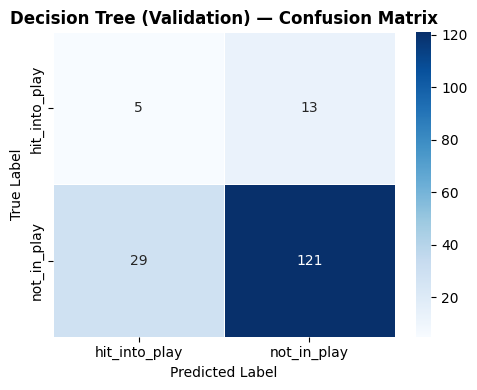

In [97]:
# ── Decision Tree Validation ───────────────────────────────────────────────
y_pred_val_dt = dt_clf.predict(X_val)
val_result_dt = evaluate_model('Decision Tree (Validation)', y_val, y_pred_val_dt,
                               class_names=list(le_val.classes_))

### 7b. Random Forest — Validation


  Random Forest (Validation)
  Accuracy  : 0.8274
  Precision : 0.8032  (weighted)
  Recall    : 0.8274  (weighted)
  F1 Score  : 0.8149  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.08      0.06      0.06        18
  not_in_play       0.89      0.92      0.90       150

     accuracy                           0.83       168
    macro avg       0.48      0.49      0.48       168
 weighted avg       0.80      0.83      0.81       168



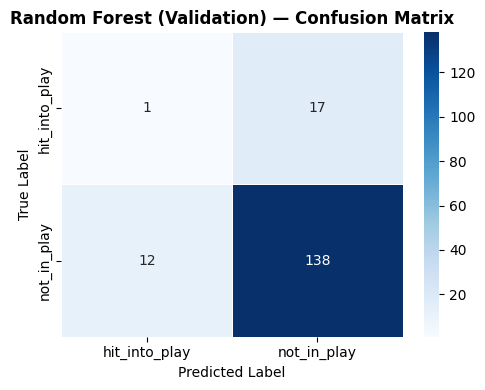

In [98]:
# ── Random Forest Validation ───────────────────────────────────────────────
y_pred_val_rf = rf_clf.predict(X_val)
val_result_rf = evaluate_model('Random Forest (Validation)', y_val, y_pred_val_rf,
                               class_names=list(le_val.classes_))

### 7c. XGBoost — Validation


  XGBoost (Validation)
  Accuracy  : 0.8929
  Precision : 0.8550  (weighted)
  Recall    : 0.8929  (weighted)
  F1 Score  : 0.8527  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.50      0.06      0.10        18
  not_in_play       0.90      0.99      0.94       150

     accuracy                           0.89       168
    macro avg       0.70      0.52      0.52       168
 weighted avg       0.85      0.89      0.85       168



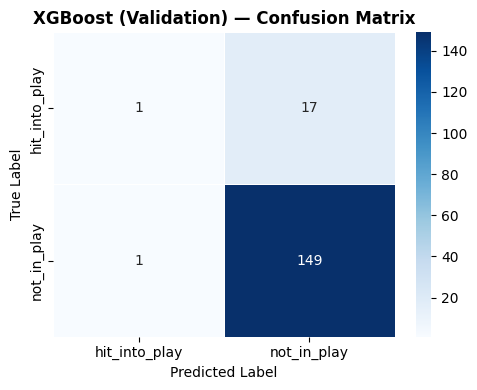

In [99]:
# ── XGBoost Validation ──────────────────────────────────────────────────────
y_pred_val_xgb = xgb_clf.predict(X_val)
val_result_xgb = evaluate_model('XGBoost (Validation)', y_val, y_pred_val_xgb,
                                class_names=list(le_val.classes_))

### 7d. LightGBM — Validation


  LightGBM (Validation)
  Accuracy  : 0.8810
  Precision : 0.8271  (weighted)
  Recall    : 0.8810  (weighted)
  F1 Score  : 0.8457  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.25      0.06      0.09        18
  not_in_play       0.90      0.98      0.94       150

     accuracy                           0.88       168
    macro avg       0.57      0.52      0.51       168
 weighted avg       0.83      0.88      0.85       168



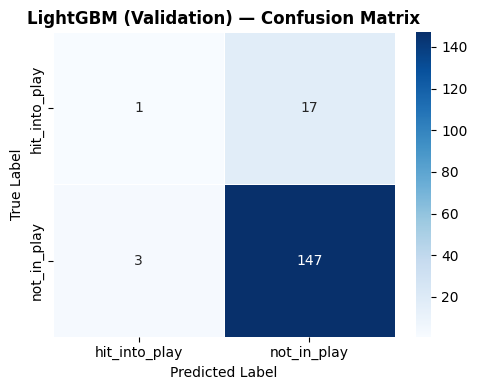

In [100]:
# ── LightGBM Validation ────────────────────────────────────────────────────
y_pred_val_lgbm = lgbm_clf.predict(X_val)
val_result_lgbm = evaluate_model('LightGBM (Validation)', y_val, y_pred_val_lgbm,
                                 class_names=list(le_val.classes_))

### 7e. CatBoost — Validation


  CatBoost (Validation)
  Accuracy  : 0.8750
  Precision : 0.7955  (weighted)
  Recall    : 0.8750  (weighted)
  F1 Score  : 0.8333  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.00      0.00      0.00        18
  not_in_play       0.89      0.98      0.93       150

     accuracy                           0.88       168
    macro avg       0.45      0.49      0.47       168
 weighted avg       0.80      0.88      0.83       168



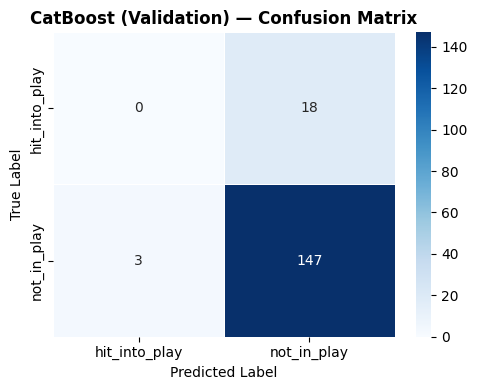

In [101]:
# ── CatBoost Validation ────────────────────────────────────────────────────
y_pred_val_cat = cat_clf.predict(X_val)
val_result_cat = evaluate_model('CatBoost (Validation)', y_val, y_pred_val_cat,
                                class_names=list(le_val.classes_))

### 7f. ANN — Validation

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

  ANN (Validation)
  Accuracy  : 0.8929
  Precision : 0.8777  (weighted)
  Recall    : 0.8929  (weighted)
  F1 Score  : 0.8832  (weighted)
               precision    recall  f1-score   support

hit_into_play       0.50      0.33      0.40        18
  not_in_play       0.92      0.96      0.94       150

     accuracy                           0.89       168
    macro avg       0.71      0.65      0.67       168
 weighted avg       0.88      0.89      0.88       168



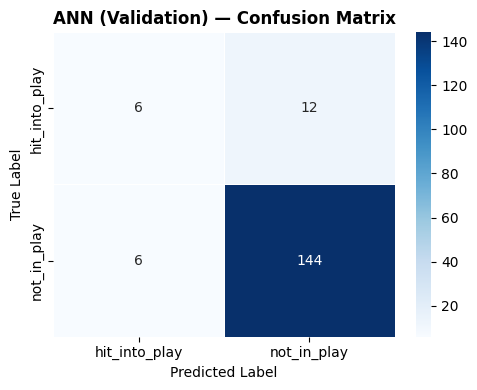

In [102]:
# ── ANN Validation ──────────────────────────────────────────────────────────
y_pred_val_ann_prob = ann.predict(X_val)
y_pred_val_ann      = (y_pred_val_ann_prob > 0.5).astype(np.int_)

val_result_ann = evaluate_model('ANN (Validation)', y_val, y_pred_val_ann,
                                class_names=list(le_val.classes_))

## 8. Full Validation Summary — All Models

Test-set performance is paired with validation performance for each model to reveal generalization gaps.

In [103]:
# ── Build Paired Test vs. Validation Summary Table ──────────────────────────────
model_pairs = [
    ('Decision Tree', next(r for r in model_results if r['model'] == 'Decision Tree'), val_result_dt),
    ('Random Forest', next(r for r in model_results if r['model'] == 'Random Forest'), val_result_rf),
    ('XGBoost',       next(r for r in model_results if r['model'] == 'XGBoost'),       val_result_xgb),
    ('LightGBM',      next(r for r in model_results if r['model'] == 'LightGBM'),      val_result_lgbm),
    ('CatBoost',      next(r for r in model_results if r['model'] == 'CatBoost'),      val_result_cat),
    ('ANN',           next(r for r in model_results if r['model'] == 'ANN'),           val_result_ann),
]

rows = []
for name, test_r, val_r in model_pairs:
    rows.append({'Model': name, 'Split': 'Test',
                 'Accuracy': test_r['accuracy'], 'Precision': test_r['precision'],
                 'Recall': test_r['recall'],     'F1': test_r['f1']})
    rows.append({'Model': name, 'Split': 'Validation',
                 'Accuracy': val_r['accuracy'],  'Precision': val_r['precision'],
                 'Recall': val_r['recall'],      'F1': val_r['f1']})

summary_df = pd.DataFrame(rows)

print('\nTest vs. Validation — All Models')
print('=' * 85)
pivoted = summary_df.pivot_table(index=['Model', 'Split'],
                                  values=['Accuracy', 'Precision', 'Recall', 'F1'])
print(pivoted.round(4).to_string())
print('=' * 85)


Test vs. Validation — All Models
                          Accuracy      F1  Precision  Recall
Model         Split                                          
ANN           Test          0.9187  0.9186     0.9194  0.9187
              Validation    0.8929  0.8832     0.8777  0.8929
CatBoost      Test          0.9236  0.9236     0.9276  0.9236
              Validation    0.8750  0.8333     0.7955  0.8750
Decision Tree Test          0.7808  0.7807     0.7807  0.7808
              Validation    0.7500  0.7814     0.8220  0.7500
LightGBM      Test          0.9138  0.9137     0.9205  0.9138
              Validation    0.8810  0.8457     0.8271  0.8810
Random Forest Test          0.8990  0.8991     0.9000  0.8990
              Validation    0.8274  0.8149     0.8032  0.8274
XGBoost       Test          0.9113  0.9112     0.9175  0.9113
              Validation    0.8929  0.8527     0.8550  0.8929


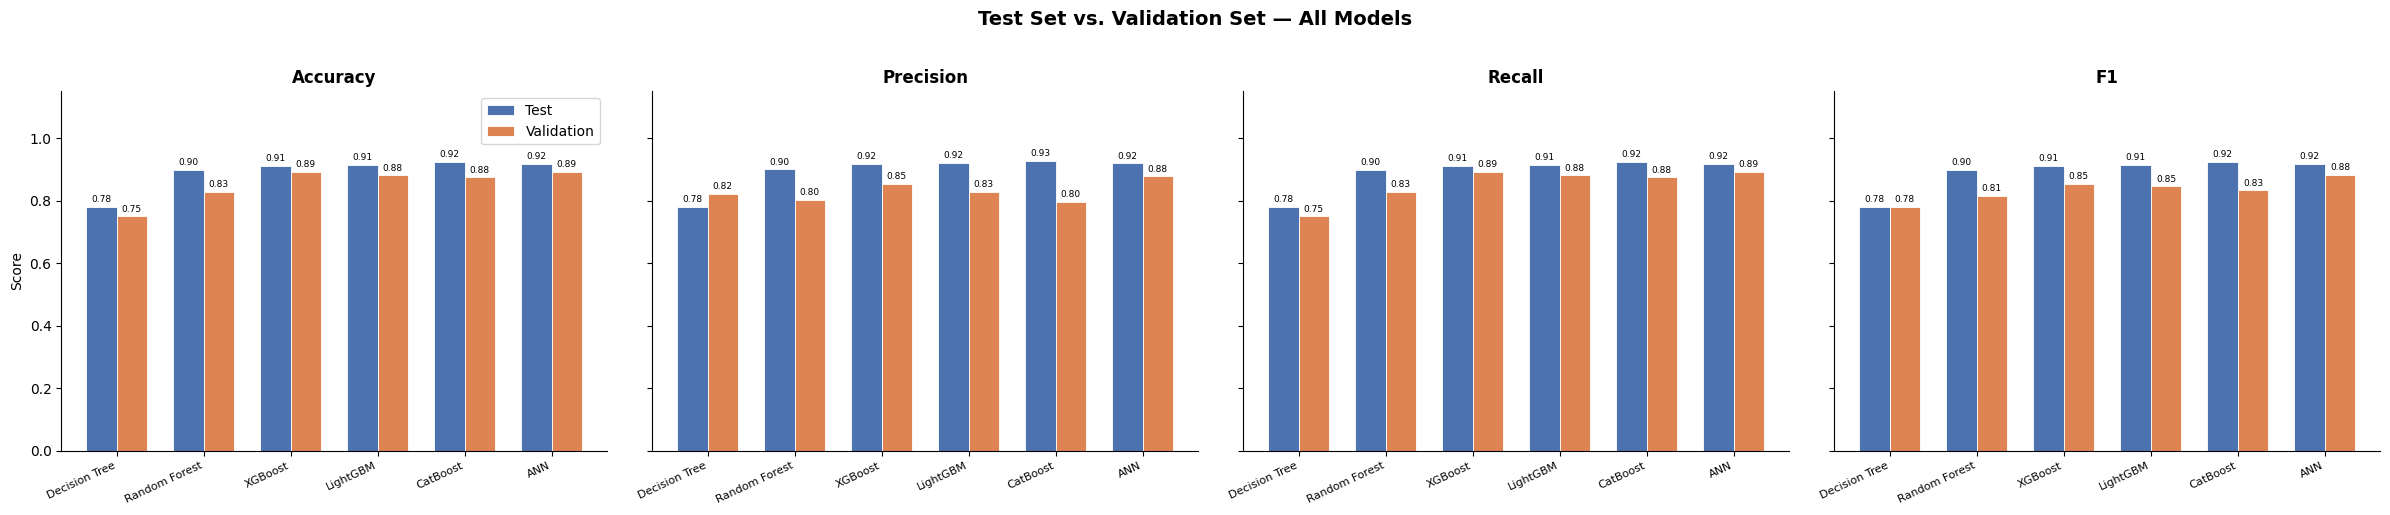

In [104]:
# ── Grouped Bar Chart: Test vs. Validation for Every Model ──────────────────────
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1']
models_list  = ['Decision Tree', 'Random Forest',
                'XGBoost', 'LightGBM', 'CatBoost', 'ANN']
n_models     = len(models_list)

fig, axes = plt.subplots(1, len(metrics_list), figsize=(24, 5), sharey=True)

colors = {'Test': '#4C72B0', 'Validation': '#DD8452'}
x      = np.arange(n_models)
width  = 0.35

for ax, metric in zip(axes, metrics_list):
    test_vals = [summary_df[(summary_df['Model'] == m) & (summary_df['Split'] == 'Test')][metric].values[0]       for m in models_list]
    val_vals  = [summary_df[(summary_df['Model'] == m) & (summary_df['Split'] == 'Validation')][metric].values[0] for m in models_list]

    bars_test = ax.bar(x - width/2, test_vals, width, label='Test',
                       color=colors['Test'],       edgecolor='white', linewidth=0.6)
    bars_val  = ax.bar(x + width/2, val_vals,  width, label='Validation',
                       color=colors['Validation'], edgecolor='white', linewidth=0.6)

    ax.bar_label(bars_test, fmt='%.2f', fontsize=6.5, padding=2)
    ax.bar_label(bars_val,  fmt='%.2f', fontsize=6.5, padding=2)

    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.spines[['top', 'right']].set_visible(False)
    if ax is axes[0]:
        ax.set_ylabel('Score')
        ax.legend()

plt.suptitle('Test Set vs. Validation Set — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_models_validation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

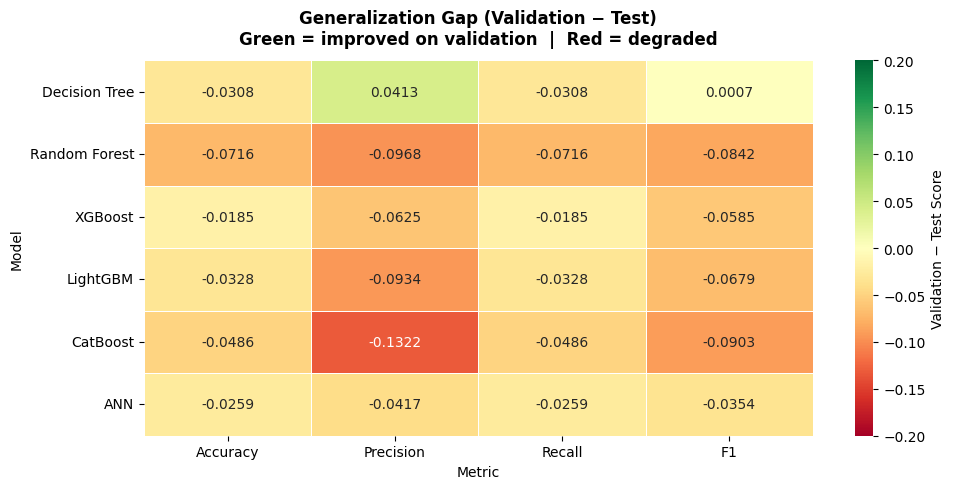


Interpretation: values near 0 indicate strong generalization.
Large negative values flag overfitting to the training window.


In [105]:
# ── Generalization Gap Heatmap ──────────────────────────────────────────────────
import seaborn as sns

gap_data = {}
for metric in metrics_list:
    gap_data[metric] = []
    for m in models_list:
        test_v = summary_df[(summary_df['Model'] == m) & (summary_df['Split'] == 'Test')][metric].values[0]
        val_v  = summary_df[(summary_df['Model'] == m) & (summary_df['Split'] == 'Validation')][metric].values[0]
        gap_data[metric].append(round(val_v - test_v, 4))

gap_df = pd.DataFrame(gap_data, index=models_list)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    gap_df, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax, vmin=-0.2, vmax=0.2,
    cbar_kws={'label': 'Validation − Test Score'}
)
ax.set_title(
    'Generalization Gap (Validation − Test)\n'
    'Green = improved on validation  |  Red = degraded',
    fontweight='bold', pad=12
)
ax.set_xlabel('Metric')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('generalization_gap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation: values near 0 indicate strong generalization.')
print('Large negative values flag overfitting to the training window.')